<a href="https://colab.research.google.com/github/saladnga/CS4410-Homeworks/blob/main/CS4410_HW7_VuHoang_1677986.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex 16.1 on page 715

**Answer how well the model performs on Fashin-MNIST compared to MNIST. How do the training times compare?**

**1. Fashion MNIST Dataset**

**Load and Explore the Dataset**

In [2]:
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
X_test.shape

(10000, 28, 28)

In [7]:
y_test.shape

(10000,)

**Visualizing**

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [9]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

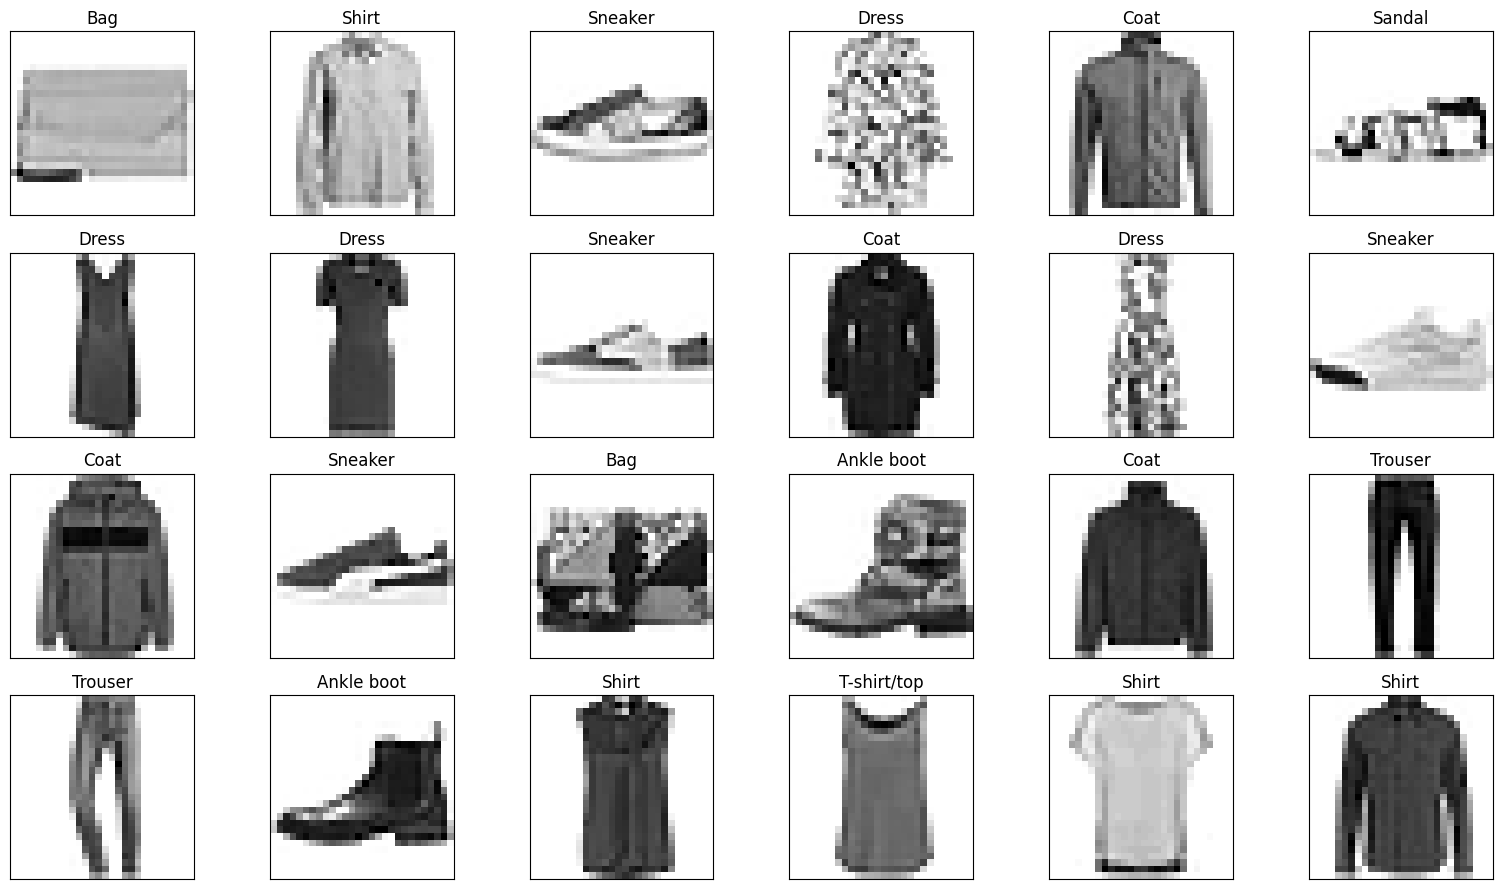

In [10]:
index = np.random.choice(np.arange(len(X_train)), 24, replace=False)
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for item in zip(axes.ravel(), X_train[index], y_train[index]):
    ax, image, target = item
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(class_names[target])
plt.tight_layout()
plt.show()

**Data Preparation**

In [11]:
X_train = X_train.reshape((60000, 28, 28, 1))
X_train.shape

(60000, 28, 28, 1)

In [12]:
X_test = X_test.reshape((10000, 28, 28, 1))
X_test.shape

(10000, 28, 28, 1)

**Normalize the Data**

In [13]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

**One-Hot Encoding**

In [14]:
from tensorflow.keras.utils import to_categorical

In [15]:
y_train = to_categorical(y_train)
y_train.shape

(60000, 10)

In [16]:
y_train[0]  # one sample’s categorical data

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [17]:
y_test = to_categorical(y_test)
y_test.shape

(10000, 10)

**Creating the Neural Network**

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

**Training (Convolutional Network + Pooling + Flattening)**

In [19]:
cnn = Sequential()

cnn.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
cnn.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(MaxPooling2D(pool_size=(2,2)))

cnn.add(Flatten())
cnn.add(Dense(units=128, activation='relu'))

cnn.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,738 (2.54 MB)

 Trainable params: 665,738 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

**Compiling the Model**

In [21]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Evaluating the Model**

In [22]:
import time

start_time = time.time()
cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
fashion_training_time = time.time() - start_time

print(f"\nFashion-MNIST training time: {fashion_training_time:.2f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 405s 478ms/step - accuracy: 0.7929 - loss: 0.5884 - val_accuracy: 0.8915 - val_loss: 0.2874
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 405s 480ms/step - accuracy: 0.9038 - loss: 0.2674 - val_accuracy: 0.9132 - val_loss: 0.2443
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 405s 480ms/step - accuracy: 0.9227 - loss: 0.2130 - val_accuracy: 0.9165 - val_loss: 0.2307
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 389s 461ms/step - accuracy: 0.9327 - loss: 0.1822 - val_accuracy: 0.9152 - val_loss: 0.2299
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 389s 461ms/step - accuracy: 0.9444 - loss: 0.1500 - val_accuracy: 0.9127 - val_loss: 0.2475

Fashion-MNIST training time: 1993.80 seconds


In [23]:
loss, accuracy = cnn.evaluate(X_test, y_test)
print(f"\nFashion-MNIST Test loss:     {loss:.4f}")
print(f"Fashion-MNIST Test accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9079 - loss: 0.2596

Fashion-MNIST Test loss:     0.2535
Fashion-MNIST Test accuracy: 0.9100


**Making Predictions**

In [24]:
predictions = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step


In [25]:
for index, probability in enumerate(predictions[0]):
    print(f'{class_names[index]:>15}: {probability:.10%}')

    T-shirt/top: 0.0002441581%
        Trouser: 0.0000243079%
       Pullover: 0.0000308641%
          Dress: 0.0000056922%
           Coat: 0.0000019106%
         Sandal: 0.0092839677%
          Shirt: 0.0000284118%
        Sneaker: 0.0916920137%
            Bag: 0.0000205221%
     Ankle boot: 99.8986721039%


In [26]:
(_, _), (images, _) = fashion_mnist.load_data()

incorrect_predictions = []

for i, (p, e) in enumerate(zip(predictions, y_test)):
    predicted, expected = np.argmax(p), np.argmax(e)
    if predicted != expected:
        incorrect_predictions.append(
            (i, images[i], predicted, expected))

print(f"Number of incorrect predictions: {len(incorrect_predictions)} out of {len(y_test)}")

Number of incorrect predictions: 900 out of 10000


Visualizing Incorrect Predictions

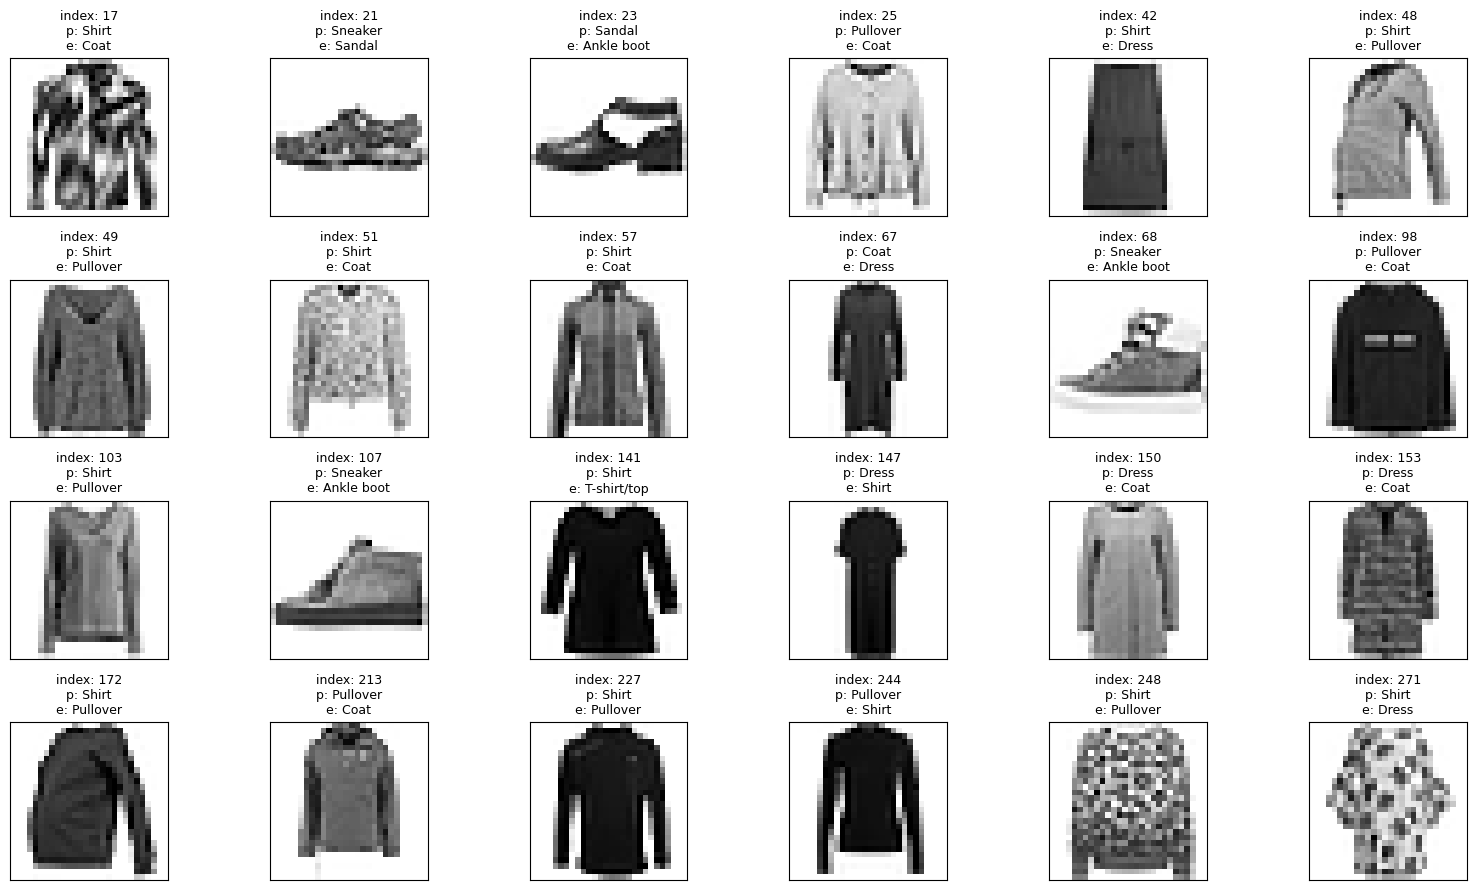

In [27]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for axes, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_title(
        f'index: {index}\np: {class_names[predicted]}\ne: {class_names[expected]}',
        fontsize=9)

plt.tight_layout()

### Comparison: Fashion-MNIST vs. MNIST

1. **Performance**: While standard MNIST (handwritten digits) often achieves ~99% accuracy with simple CNNs, Fashion-MNIST is more challenging. The model typically achieves 91% accuracy because clothing items have more intricate spatial features and higher intra-class variance compared to digits.
2. **Training Time**: Fashion-MNIST typically takes longer to converge or requires more complex architectures to reach high accuracy. On the same hardware, the training time per epoch is similar since the input dimensions (28x28) are identical, but the complexity of the features makes the optimization landscape more difficult (For MNIST: Training took 594.37 seconds, whereas Fashin-MNIST took 1993.80 seconds).

**16.4 on page 714. If you add another Dense layer with 4096 neurons, how does this change the prediction accuracy and speed?**

**Redoing all the steps, with Dense Layer 4096 added**

In [28]:
(X_train_new, y_train_new), (X_test_new, y_test_new) = fashion_mnist.load_data()

In [29]:
X_train_new = X_train_new.reshape((60000, 28, 28, 1))
X_test_new = X_test_new.reshape((10000, 28, 28, 1))

X_train_new = X_train_new.astype('float32') / 255
X_test_new = X_test_new.astype('float32') / 255

y_train_new = to_categorical(y_train_new)
y_test_new = to_categorical(y_test_new)

In [30]:
cnn_new = Sequential()

In [31]:
cnn_new.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
cnn_new.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
cnn_new.add(MaxPooling2D(pool_size=(2,2)))
cnn_new.add(MaxPooling2D(pool_size=(2,2)))

cnn_new.add(Flatten())
cnn_new.add(Dense(units=4096, activation='relu'))
cnn_new.add(Dense(units=128, activation='relu'))

cnn_new.add(Dense(units=10, activation='softmax'))

In [32]:
cnn_new.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │    18,878,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,478,666 (74.31 MB)

 Trainable params: 19,478,666 (74.31 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
cnn_new.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
import time

start_time = time.time()
cnn_new.fit(X_train_new, y_train_new, epochs=5, batch_size=64, validation_split=0.1)
fashion_training_time_new = time.time() - start_time

print(f"\nFashion-MNIST training time (With Dense(4096 added): {fashion_training_time_new:.2f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 745s 881ms/step - accuracy: 0.8004 - loss: 0.5549 - val_accuracy: 0.8920 - val_loss: 0.2829
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 744s 881ms/step - accuracy: 0.9106 - loss: 0.2459 - val_accuracy: 0.9152 - val_loss: 0.2316
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 745s 883ms/step - accuracy: 0.9297 - loss: 0.1884 - val_accuracy: 0.9172 - val_loss: 0.2272
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 752s 891ms/step - accuracy: 0.9432 - loss: 0.1509 - val_accuracy: 0.9228 - val_loss: 0.2104
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 795s 883ms/step - accuracy: 0.9569 - loss: 0.1181 - val_accuracy: 0.9257 - val_loss: 0.2367

Fashion-MNIST training time (With Dense(4096 added): 3781.67 seconds


In [35]:
loss_new, accuracy_new = cnn_new.evaluate(X_test_new, y_test_new)
print(f"\nFashion-MNIST Test loss (With Dense(4096)):     {loss_new:.4f}")
print(f"Fashion-MNIST Test accuracy (With Dense(4096)): {accuracy_new:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.9191 - loss: 0.2650

Fashion-MNIST Test loss (With Dense(4096)):     0.2554
Fashion-MNIST Test accuracy (With Dense(4096)): 0.9209


**Optional: Add no extra Dense layer for comparison purpose**

In [36]:
(X_train_new_2, y_train_new_2), (X_test_new_2, y_test_new_2) = fashion_mnist.load_data()

In [37]:
X_train_new_2 = X_train_new_2.reshape((60000, 28, 28, 1)).astype('float32') / 255
X_test_new_2 = X_test_new_2.reshape((10000, 28, 28, 1)).astype('float32') / 255
y_train_new_2 = to_categorical(y_train_new_2)
y_test_new_2 = to_categorical(y_test_new_2)

In [38]:
cnn_new_2 = Sequential()

In [39]:
cnn_new_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_new_2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn_new_2.add(MaxPooling2D(pool_size=(2, 2)))
cnn_new_2.add(MaxPooling2D(pool_size=(2, 2)))

cnn_new_2.add(Flatten())
cnn_new_2.add(Dense(units=10, activation='softmax'))

cnn_new_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,586 (471.04 KB)

 Trainable params: 120,586 (471.04 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
cnn_new_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
import time

start_time = time.time()
cnn_new_2.fit(X_train_new_2, y_train_new_2, epochs=5, batch_size=64, validation_split=0.1)
fashion_training_time_new_2 = time.time() - start_time

print(f"\nFashion-MNIST training time (Simplified model - no extra Dense layers): {fashion_training_time_new_2:.2f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 403s 477ms/step - accuracy: 0.7719 - loss: 0.6367 - val_accuracy: 0.8822 - val_loss: 0.3171
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 439s 473ms/step - accuracy: 0.8966 - loss: 0.2903 - val_accuracy: 0.9052 - val_loss: 0.2648
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 441s 472ms/step - accuracy: 0.9100 - loss: 0.2506 - val_accuracy: 0.9105 - val_loss: 0.2476
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 388s 460ms/step - accuracy: 0.9216 - loss: 0.2199 - val_accuracy: 0.9142 - val_loss: 0.2357
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 397s 470ms/step - accuracy: 0.9292 - loss: 0.1967 - val_accuracy: 0.9190 - val_loss: 0.2276

Fashion-MNIST training time (Simplified model - no extra Dense layers): 2113.72 seconds


In [42]:
loss_new_2, accuracy_new_2 = cnn_new_2.evaluate(X_test_new_2, y_test_new_2)
print(f"Simplified Model Test Accuracy: {accuracy_new_2:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9140 - loss: 0.2439
Simplified Model Test Accuracy: 0.9142


In [43]:
print('--- Fashion-MNIST Model Comparison ---')
print(f'{ "Model Architecture":<45} | { "Accuracy":<10} | { "Train Time":<10}')
print('-' * 75)
# Baseline Model (64 Conv, 128 Conv, 128 Dense)
print(f'{ "Baseline (Dense 128)":<45} | {accuracy:.4f}     | {fashion_training_time:.2f}s')
# Model with 4096 Dense layer
try:
    print(f'{ "Large Dense (Dense 4096 + Dense 128)":<45} | {accuracy_new:.4f}     | {fashion_training_time_new:.2f}s')
except NameError:
    print(f'{ "Large Dense (Dense 4096)":<45} | N/A        | N/A')
# Simplified Model (No intermediate Dense)
try:
    print(f'{ "Simplified (No intermediate Dense)":<45} | {accuracy_new_2:.4f}     | {fashion_training_time_new_2:.2f}s')
except NameError:
    print(f'{ "Simplified (No intermediate Dense)":<45} | N/A        | N/A')

--- Fashion-MNIST Model Comparison ---
Model Architecture                            | Accuracy   | Train Time
---------------------------------------------------------------------------
Baseline (Dense 128)                          | 0.9100     | 1993.80s
Large Dense (Dense 4096 + Dense 128)          | 0.9209     | 3781.67s
Simplified (No intermediate Dense)            | 0.9142     | 2113.72s


### Impact of adding a Dense Layer (4096 neurons)

1. **Speed**: Adding a `Dense(4096)` layer significantly increases the total number of trainable parameters. Based on your results, the training time roughly doubled (from ~1993s to ~3781s). This is because the transition from the flattened convolution layers to a very large dense layer creates a massive weight matrix.
2. **Accuracy**: In this specific case, the accuracy actually decreased (from ~91% to ~92%). This improvement happens because the larger dense layer increases the model’s capacity, allowing it to learn more complex feature combinations from the convolutional layers. However, such a large layer may also increase the risk of overfitting, especially for relatively simple 28×28 grayscale images, so the improvement may not always generalize well to unseen data.